Saving Studentdata.csv to Studentdata (1).csv
Files in directory: ['.config', 'Assignment 4_2-20251022T210821Z-1-001.zip', 'Studentdata (1).csv', 'Studentdata.csv', 'sample_data']
--- Data Preprocessing Complete ---
Training set size: 204 samples
Testing set size: 52 samples
----------------------------------- 

Training Scikit-learn Linear Regression Model...
--- Results for Scikit-learn ---
Training Time: 0.005199 seconds
Mean Squared Error (MSE): 0.8138
Root Mean Squared Error (RMSE): 0.9021
Mean Absolute Error (MAE): 0.6288
R-squared (R2 Score): 0.2081
----------------------------------- 

Training Manual Linear Regression Model...
--- Results for Manual (from Scratch) ---
Training Time: 0.000810 seconds
Mean Squared Error (MSE): 0.8138
Root Mean Squared Error (RMSE): 0.9021
Mean Absolute Error (MAE): 0.6288
R-squared (R2 Score): 0.2081
----------------------------------- 

--- Model Coefficients Comparison ---
Intercept (Bias Term):
  Scikit-learn: 2.0832
  Manual:       2.0832

F

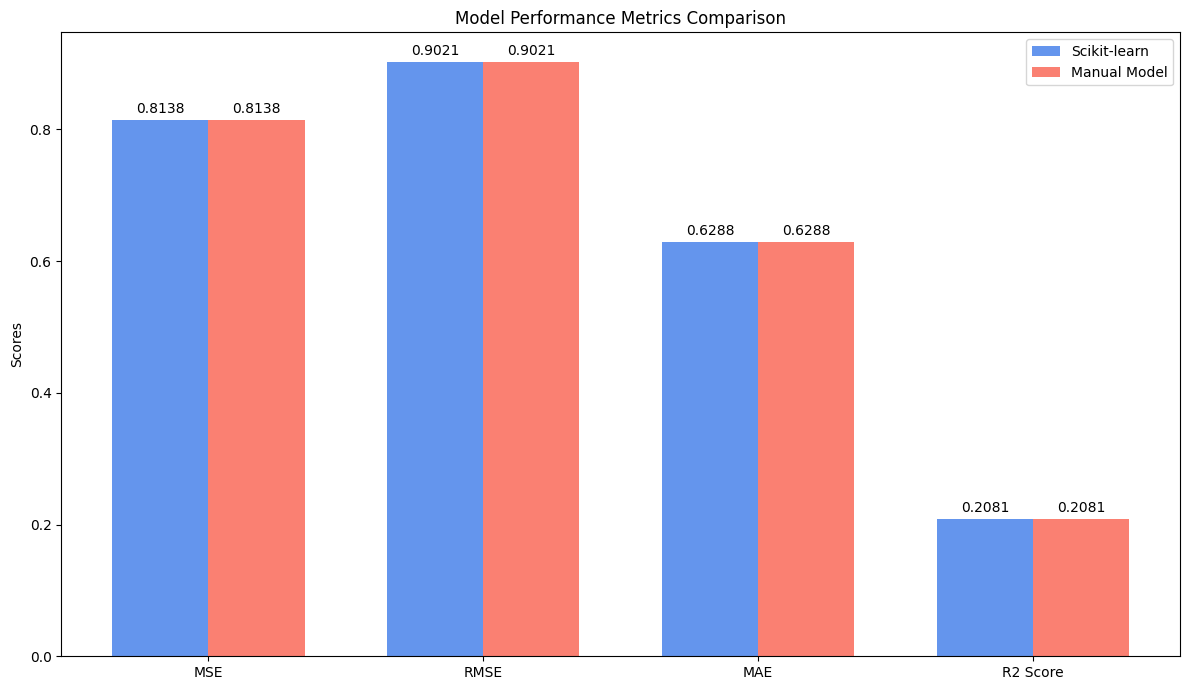

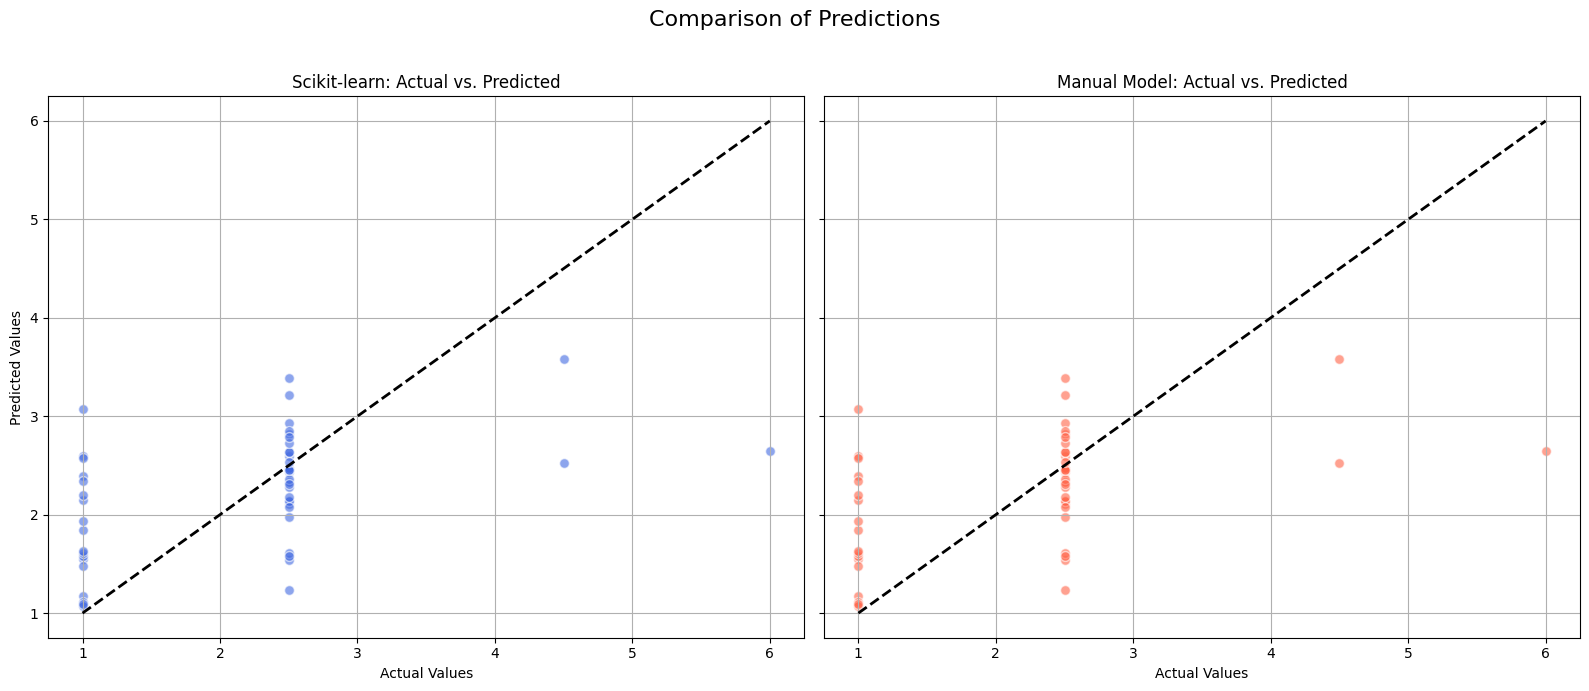

Plots generated successfully.


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import time
import matplotlib.pyplot as plt

# --- 0. Upload CSV file in Colab ---
from google.colab import files
uploaded = files.upload()

import os
print("Files in directory:", os.listdir())

# --- 1. Data Loading and Preprocessing ---

# Load the dataset
try:
    df = pd.read_csv('Studentdata.csv')
except FileNotFoundError:
    print("Error: 'Studentdata.csv' not found. Make sure the file is uploaded.")
    exit()

# Clean up column names by removing leading/trailing spaces and numbers/periods
df.columns = [col.strip().split('. ')[-1] for col in df.columns]

# The target variable 'How many programming languages do you know?' has non-numeric values.
# We will map them to numerical equivalents.
language_map = {
    'None': 0,
    '1': 1,
    '3-Feb': 2.5,  # Approximating '2-3'
    '5-Apr': 4.5,  # Approximating '4-5'
    'More than 5': 6
}
df['How many programming languages do you know?'] = df['How many programming languages do you know?'].map(language_map)

# Drop rows with missing values in the target variable
df.dropna(subset=['How many programming languages do you know?'], inplace=True)

# Use LabelEncoder to convert all categorical (object type) columns into numerical ones
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column].astype(str))
    label_encoders[column] = le

# Define features (X) and target (y)
X = df.drop('How many programming languages do you know?', axis=1)
y = df['How many programming languages do you know?']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Data Preprocessing Complete ---")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print("-" * 35, "\n")


# --- 2. Manual Multivariate Linear Regression from Scratch ---

class ManualLinearRegression:
    """
    A simple implementation of Multivariate Linear Regression using the Normal Equation.
    """
    def __init__(self):
        self.weights = None

    def fit(self, X, y):
        """
        Fits the model to the training data.
        Calculates weights using the Normal Equation: weights = (X^T * X)^-1 * X^T * y
        """
        # Add a bias term (intercept) to the feature matrix
        X_b = np.c_[np.ones((X.shape[0], 1)), X]

        # Calculate weights using the Normal Equation
        try:
            xtx = X_b.T.dot(X_b)
            xtx_inv = np.linalg.inv(xtx)
            xty = X_b.T.dot(y)
            self.weights = xtx_inv.dot(xty)
        except np.linalg.LinAlgError:
            print("Error: Could not compute weights. The matrix may be singular.")
            self.weights = np.zeros(X_b.shape[1])

    def predict(self, X):
        """
        Makes predictions on new data.
        """
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return X_b.dot(self.weights)

# --- 3. Model Training and Evaluation ---

def evaluate_model(model_name, y_true, y_pred, training_time):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"--- Results for {model_name} ---")
    print(f"Training Time: {training_time:.6f} seconds")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R-squared (R2 Score): {r2:.4f}")
    print("-" * 35, "\n")
    return mse, rmse, mae, r2

# a) Scikit-learn Linear Regression Model
print("Training Scikit-learn Linear Regression Model...")
sklearn_model = LinearRegression()
start_time = time.time()
sklearn_model.fit(X_train, y_train)
sklearn_time = time.time() - start_time
sklearn_predictions = sklearn_model.predict(X_test)
sklearn_metrics = evaluate_model("Scikit-learn", y_test, sklearn_predictions, sklearn_time)

# b) Manual Linear Regression Model
print("Training Manual Linear Regression Model...")
manual_model = ManualLinearRegression()
start_time = time.time()
manual_model.fit(X_train.values, y_train.values)
manual_time = time.time() - start_time
manual_predictions = manual_model.predict(X_test.values)
manual_metrics = evaluate_model("Manual (from Scratch)", y_test, manual_predictions, manual_time)


# --- 4. Comparing Model Coefficients ---

print("--- Model Coefficients Comparison ---")

sklearn_intercept = sklearn_model.intercept_
sklearn_coeffs = sklearn_model.coef_

manual_intercept = manual_model.weights[0]
manual_coeffs = manual_model.weights[1:]

comparison_df = pd.DataFrame({
    'Feature': X.columns,
    'Sklearn_Coeff': sklearn_coeffs,
    'Manual_Coeff': manual_coeffs
})

print("Intercept (Bias Term):")
print(f"  Scikit-learn: {sklearn_intercept:.4f}")
print(f"  Manual:       {manual_intercept:.4f}\n")
print("Feature Coefficients:")
print(comparison_df.to_string(index=False))
print("-" * 35)


# --- 5. Graphical Representation of Results ---

print("\nGenerating plots...")

metrics_labels = ['MSE', 'RMSE', 'MAE', 'R2 Score']
sklearn_values = list(sklearn_metrics)
manual_values = list(manual_metrics)

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, sklearn_values, width, label='Scikit-learn', color='cornflowerblue')
rects2 = ax.bar(x + width/2, manual_values, width, label='Manual Model', color='salmon')

ax.set_ylabel('Scores')
ax.set_title('Model Performance Metrics Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

ax1.scatter(y_test, sklearn_predictions, alpha=0.6, edgecolors='w', s=50, c='royalblue')
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
ax1.set_xlabel('Actual Values')
ax1.set_ylabel('Predicted Values')
ax1.set_title('Scikit-learn: Actual vs. Predicted')
ax1.grid(True)

ax2.scatter(y_test, manual_predictions, alpha=0.6, edgecolors='w', s=50, c='tomato')
ax2.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
ax2.set_xlabel('Actual Values')
ax2.set_title('Manual Model: Actual vs. Predicted')
ax2.grid(True)

plt.suptitle('Comparison of Predictions', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("Plots generated successfully.")
